# Retorno do ITUB4 e Fatores de Risco — Modelo Multifator com Regularização

**Módulo:** 01 — Machine Learning | **Análise:** 02 | **Data:** 2026-05-31

---

## Contexto

Na [análise anterior](01_predicao_choque_itub4.md), usamos o CAPM com um único fator — o retorno do Ibovespa — para explicar o retorno do ITUB4. É um bom ponto de partida, mas simplista: ignora que tamanho, valor, momentum e liquidez também afetam o preço das ações.

Aqui ampliamos o modelo para **5 fatores de risco** fornecidos pelo [NEFIN/USP](https://nefin.com.br). Com mais preditores correlacionados entre si, o OLS começa a produzir coeficientes instáveis — risco de overfitting. É exatamente o cenário onde Ridge, Lasso e Elastic Net mostram seu valor.

## Pergunta de negócio

> **Quais fatores de risco explicam o retorno em excesso do ITUB4 — e com que peso?**

Para responder isso com rigor, precisamos de um modelo que generalize para períodos futuros, não apenas que ajuste os dados de treino.

## Estrutura da análise (CRISP-DM)

| Fase | O que fazemos |
|------|---------------|
| 1 — Entendimento do negócio | Definição do problema e do modelo alvo |
| 2 — Entendimento dos dados  | Download, inspeção, EDA |
| 3 — Preparação dos dados    | Divisão temporal, padronização |
| 4 — Modelagem               | OLS (baseline), Ridge, Lasso, Elastic Net |
| 5 — Avaliação               | Métricas, regularization paths, coeficientes, estabilidade temporal, robustez de frequência e janela deslizante |
| 6 — Conclusão               | Quais fatores importam e o que a regularização revelou |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import requests, io, warnings
warnings.filterwarnings('ignore')

import yfinance as yf
from sklearn.linear_model import (LinearRegression,
                                   Ridge, Lasso, ElasticNet,
                                   RidgeCV, LassoCV, ElasticNetCV)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error

# ── paleta escura padrão do repositório ───────────────────────────────────
BG    = '#0d1117'
BLUE  = '#58a6ff'
RED   = '#f78166'
GREEN = '#3fb950'
GRAY  = '#8b949e'
TEXT  = '#e6edf3'
GRID  = '#21262d'
GOLD  = '#ffa657'

plt.rcParams.update({
    'figure.facecolor':  BG,
    'axes.facecolor':    BG,
    'axes.edgecolor':    GRID,
    'axes.labelcolor':   TEXT,
    'xtick.color':       TEXT,
    'ytick.color':       TEXT,
    'text.color':        TEXT,
    'grid.color':        GRID,
    'grid.alpha':        0.4,
    'legend.facecolor':  '#161b22',
    'legend.edgecolor':  GRID,
    'legend.labelcolor': TEXT,
    'font.size':         11,
})

## Fase 1 — Entendimento do Negócio

O modelo que vamos estimar é uma extensão direta do CAPM:

$$R_{\text{ITUB4},t} - R_{f,t} = \alpha + \beta_1 (R_{m,t} - R_{f,t}) + \beta_2 \text{SMB}_t + \beta_3 \text{HML}_t + \beta_4 \text{WML}_t + \beta_5 \text{IML}_t + \varepsilon_t$$

| Fator | Significado | Intuição |
|-------|-------------|----------|
| $R_m - R_f$ | Prêmio de mercado | Quanto o Ibovespa rendeu acima do ativo livre de risco |
| SMB | *Small minus big* — prêmio de tamanho | Ações pequenas tendem a render mais |
| HML | *High minus low* — prêmio de valor | Ações baratas (P/VP baixo) tendem a render mais |
| WML | *Winners minus losers* — momentum | Ações que subiram continuam subindo no curto prazo |
| IML | *Illiquid minus liquid* — iliquidez | Ações ilíquidas pagam prêmio de liquidez |

Com 5 preditores e correlações entre eles, usar OLS sem restrições pode produzir coeficientes inflados ou instáveis. A regularização vai nos dizer quais fatores realmente importam para o ITUB4 — e com que magnitude.

## Fase 2 — Entendimento dos Dados

### 2.1 Fatores de risco (NEFIN/USP)

In [2]:
url_nefin = 'https://nefin.com.br/resources/risk_factors/nefin_factors.csv'
nefin = pd.read_csv(url_nefin, parse_dates=['Date'], index_col='Date')

print(f"Período: {nefin.index.min().date()} → {nefin.index.max().date()}")
print(f"Observações: {len(nefin):,}")
print(f"\nFatores disponíveis: {list(nefin.columns)}")
nefin.head(3)

Período: 2001-01-02 → 2026-05-05
Observações: 6,279

Fatores disponíveis: ['Unnamed: 0', 'Rm_minus_Rf', 'SMB', 'HML', 'WML', 'IML', 'Risk_Free']


,Unnamed: 0,Rm_minus_Rf,SMB,HML,WML,IML,Risk_Free
Date,,,,,,,
2001-01-02,1,0.006601,0.115837,0.050887,-0.004917,0.007878,0.000579
2001-01-03,2,0.062427,0.038310,0.019596,-0.037093,0.018070,0.000577
2001-01-04,3,-0.000310,-0.014067,-0.009731,-0.000441,-0.014372,0.000574


### 2.2 Retornos do ITUB4 e construção do dataset

In [3]:
# Download ITUB4 (retorno diário)
raw = yf.download('ITUB4.SA', start='2010-01-01', auto_adjust=True, progress=False)
close = raw['Close']
if isinstance(close, pd.DataFrame):
    close = close.squeeze()
itub4 = close.pct_change().dropna()
itub4.name = 'R_ITUB4'
if hasattr(itub4.index, 'tz') and itub4.index.tz is not None:
    itub4.index = itub4.index.tz_localize(None)

# Merge com fatores NEFIN (intersecção de datas)
df = nefin.join(itub4, how='inner').loc['2010-01-01':]

# Retorno em excesso do ITUB4: R_ITUB4 - taxa livre de risco diária
df['R_excess'] = df['R_ITUB4'] - df['Risk_Free']
df = df.dropna()

print(f"Amostra final: {df.index.min().date()} → {df.index.max().date()}")
print(f"Observações: {len(df):,} dias úteis\n")
print(df[['Rm_minus_Rf', 'SMB', 'HML', 'WML', 'IML', 'R_excess']].describe().round(5))

Amostra final: 2010-01-05 → 2026-05-05
Observações: 4,047 dias úteis

       Rm_minus_Rf         SMB         HML         WML         IML    R_excess
count   4047.00000  4047.00000  4047.00000  4047.00000  4047.00000  4047.00000
mean       0.00004    -0.00011     0.00023     0.00073    -0.00000     0.00025
std        0.01358     0.00999     0.00741     0.00976     0.00811     0.01889
min       -0.14719    -0.06323    -0.04233    -0.07698    -0.05592    -0.17989
25%       -0.00711    -0.00585    -0.00412    -0.00450    -0.00504    -0.01027
50%        0.00014    -0.00025     0.00020     0.00113     0.00005    -0.00011
75%        0.00734     0.00521     0.00453     0.00626     0.00499     0.01046
max        0.13474     0.23367     0.04088     0.06330     0.04832     0.11742


### 2.3 Retorno acumulado em excesso

Antes de modelar, vale visualizar como o ITUB4 se move em relação ao prêmio de mercado ao longo do tempo. Se o CAPM de 1 fator fosse suficiente, as duas curvas deveriam andar juntas — divergências indicam que outros fatores têm papel.

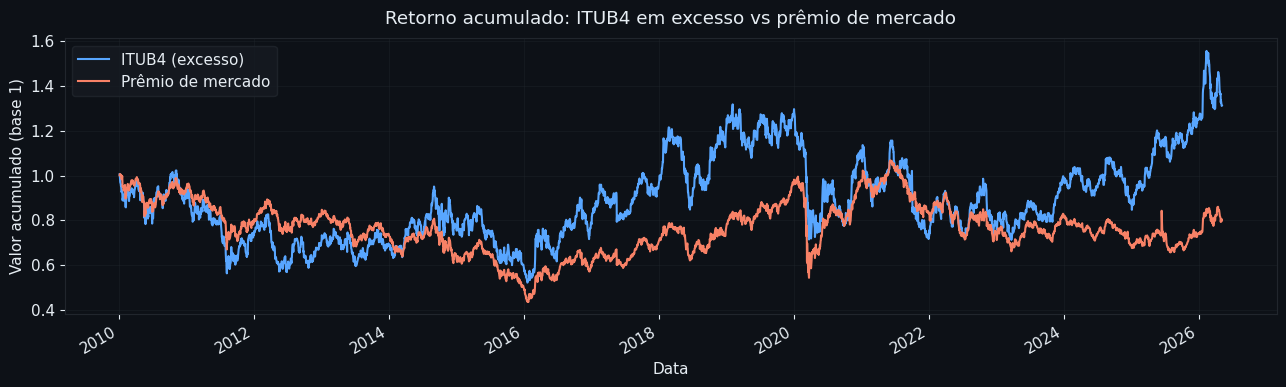


Os períodos em que as curvas divergem são os mais informativos:
neles, outros fatores (SMB, HML, WML, IML) provavelmente explicam parte do retorno.


In [4]:
fig, ax = plt.subplots(figsize=(13, 4))

(1 + df['R_excess']).cumprod().plot(ax=ax, color=BLUE,  lw=1.5, label='ITUB4 (excesso)')
(1 + df['Rm_minus_Rf']).cumprod().plot(ax=ax, color=RED, lw=1.5, label='Prêmio de mercado')

ax.set_title('Retorno acumulado: ITUB4 em excesso vs prêmio de mercado', color=TEXT, pad=10)
ax.set_xlabel('Data', color=TEXT)
ax.set_ylabel('Valor acumulado (base 1)', color=TEXT)
ax.legend()
ax.grid(True)
fig.patch.set_facecolor(BG)
plt.tight_layout()
plt.show()

print("\nOs períodos em que as curvas divergem são os mais informativos:")
print("neles, outros fatores (SMB, HML, WML, IML) provavelmente explicam parte do retorno.")

### 2.4 Correlação entre os fatores

Fatores correlacionados são o principal problema do OLS com muitos preditores: coeficientes ficam instáveis porque o modelo não consegue separar o efeito de cada um. A regularização lida com isso diretamente.

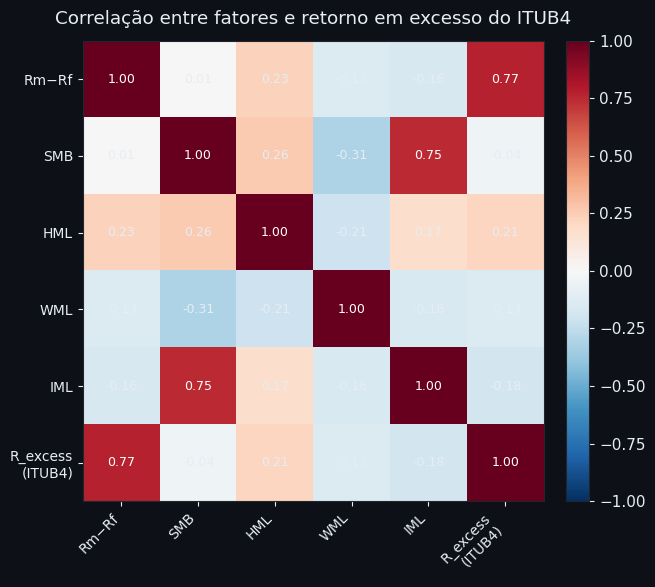


Fatores com correlação alta entre si → multicolinearidade → motivação para regularização.


In [5]:
FEATURES = ['Rm_minus_Rf', 'SMB', 'HML', 'WML', 'IML']
labels    = ['Rm−Rf', 'SMB', 'HML', 'WML', 'IML']

corr = df[FEATURES + ['R_excess']].corr()
labels_full = labels + ['R_excess\n(ITUB4)']

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set_xticks(range(len(labels_full)))
ax.set_yticks(range(len(labels_full)))
ax.set_xticklabels(labels_full, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(labels_full, fontsize=10)

for i in range(len(labels_full)):
    for j in range(len(labels_full)):
        val = corr.values[i, j]
        cor_txt = 'white' if abs(val) > 0.45 else TEXT
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                color=cor_txt, fontsize=9)

ax.set_title('Correlação entre fatores e retorno em excesso do ITUB4', color=TEXT, pad=12)
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
plt.tight_layout()
plt.show()

print("\nFatores com correlação alta entre si → multicolinearidade → motivação para regularização.")

## Fase 3 — Preparação dos Dados

Dois cuidados obrigatórios antes de regularizar:

**1. Divisão temporal (não aleatória)**
Dados financeiros têm ordem temporal. Embaralhar as observações vazaria informação do futuro para o treino. Usamos os primeiros 80% dos dias para treino e os últimos 20% para teste — respeitando a cronologia.

**2. Padronização dos preditores**
A penalidade de regularização trata todos os coeficientes na mesma escala. Se um fator tem desvio-padrão 10x maior que outro, seu coeficiente seria punido 10x menos — distorcendo os resultados. Padronizamos os preditores (média zero, desvio-padrão um) **apenas com os dados de treino**: aplicar a mesma transformação no teste evita vazamento (*data leakage*).

In [6]:
# Variáveis
X = df[FEATURES].values
y = df['R_excess'].values

# Divisão temporal 80 / 20
split = int(len(df) * 0.80)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

date_train_end = df.index[split - 1].date()
date_test_start = df.index[split].date()

# Padronização: fit apenas no treino
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Treino: {df.index[0].date()} → {date_train_end}  ({split:,} observações)")
print(f"Teste:  {date_test_start} → {df.index[-1].date()}  ({len(df) - split:,} observações)")
print(f"\nMédia dos preditores no treino após padronização: {X_train_sc.mean(axis=0).round(6)}")
print(f"Desvio-padrão dos preditores no treino:            {X_train_sc.std(axis=0).round(6)}")

Treino: 2010-01-05 → 2023-01-31  (3,237 observações)
Teste:  2023-02-01 → 2026-05-05  (810 observações)

Média dos preditores no treino após padronização: [-0. -0.  0. -0. -0.]
Desvio-padrão dos preditores no treino:            [1. 1. 1. 1. 1.]


## Fase 4 — Modelagem

Ajustamos quatro modelos na seguinte ordem: OLS como baseline (sem regularização), depois Ridge, Lasso e Elastic Net com λ calibrado por validação cruzada temporal.

### 4.1 OLS — baseline sem regularização

O OLS estima os coeficientes minimizando apenas o SSR, sem nenhuma restrição. Serve como referência: qualquer modelo regularizado deve superar o OLS no conjunto de teste — caso contrário, a penalidade está excessiva.

In [7]:
ols = LinearRegression()
ols.fit(X_train_sc, y_train)

print("Coeficientes OLS (preditores padronizados):")
for nome, coef in zip(FEATURES, ols.coef_):
    print(f"  {nome:<15} {coef:+.6f}")
print(f"  Intercepto:     {ols.intercept_:+.6f}")
print(f"\nR² treino: {r2_score(y_train, ols.predict(X_train_sc)):.4f}")
print(f"R² teste:  {r2_score(y_test,  ols.predict(X_test_sc)):.4f}")

Coeficientes OLS (preditores padronizados):
  Rm_minus_Rf     +0.015334
  SMB             -0.000178
  HML             +0.000677
  WML             -0.000972
  IML             -0.001387
  Intercepto:     +0.000129

R² treino: 0.6406
R² teste:  0.2766


### 4.2 Ridge — shrinkage sem eliminação

A penalidade L2 encolhe todos os coeficientes em direção a zero, mas nenhum chega a zero exatamente. Útil quando todos os fatores têm alguma relevância e queremos estabilizar os coeficientes sem excluir variáveis.

O λ ótimo é encontrado por **validação cruzada temporal** (`TimeSeriesSplit`): os dados de treino são divididos em janelas cronológicas, preservando a ordem do tempo em cada fold.

In [8]:
tscv   = TimeSeriesSplit(n_splits=5)
alphas = np.logspace(-4, 4, 200)

ridge_cv = RidgeCV(alphas=alphas, cv=tscv, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train_sc, y_train)

print(f"λ ótimo (Ridge): {ridge_cv.alpha_:.6f}")
print("\nCoeficientes Ridge:")
for nome, coef in zip(FEATURES, ridge_cv.coef_):
    print(f"  {nome:<15} {coef:+.6f}")
print(f"\nR² treino: {r2_score(y_train, ridge_cv.predict(X_train_sc)):.4f}")
print(f"R² teste:  {r2_score(y_test,  ridge_cv.predict(X_test_sc)):.4f}")

λ ótimo (Ridge): 56.071699

Coeficientes Ridge:
  Rm_minus_Rf     +0.015047
  SMB             -0.000159
  HML             +0.000737
  WML             -0.000973
  IML             -0.001446

R² treino: 0.6404
R² teste:  0.2861


### 4.3 Lasso — seleção de variáveis

A penalidade L1 zera coeficientes cujo benefício para o SSR é menor que λ. O resultado é um modelo **esparso**: apenas os fatores com contribuição suficiente sobrevivem. Isso responde diretamente à nossa pergunta — quais fatores importam para o ITUB4?

In [9]:
lasso_cv = LassoCV(alphas=alphas, cv=tscv, max_iter=20000)
lasso_cv.fit(X_train_sc, y_train)

print(f"λ ótimo (Lasso): {lasso_cv.alpha_:.6f}")
print("\nCoeficientes Lasso:")
for nome, coef in zip(FEATURES, lasso_cv.coef_):
    status = '  ← zerado' if coef == 0 else ''
    print(f"  {nome:<15} {coef:+.6f}{status}")

n_zeros = np.sum(lasso_cv.coef_ == 0)
print(f"\nFatores eliminados: {n_zeros} de {len(FEATURES)}")
print(f"\nR² treino: {r2_score(y_train, lasso_cv.predict(X_train_sc)):.4f}")
print(f"R² teste:  {r2_score(y_test,  lasso_cv.predict(X_test_sc)):.4f}")

λ ótimo (Lasso): 0.001012

Coeficientes Lasso:
  Rm_minus_Rf     +0.014792
  SMB             -0.000000  ← zerado
  HML             +0.000000  ← zerado
  WML             -0.000018
  IML             -0.000454

Fatores eliminados: 2 de 5

R² treino: 0.6328
R² teste:  0.3048


### 4.4 Elastic Net — equilíbrio entre Ridge e Lasso

Combina as penalidades L1 e L2. O parâmetro `l1_ratio` (nosso α) controla o mix: valores próximos de 1 aproximam o Lasso; próximos de 0, o Ridge. O Elastic Net é especialmente útil quando há grupos de fatores correlacionados — ao invés de escolher arbitrariamente um, distribui o peso entre eles.

In [10]:
enet_cv = ElasticNetCV(
    alphas=alphas,
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
    cv=tscv,
    max_iter=20000
)
enet_cv.fit(X_train_sc, y_train)

print(f"λ ótimo (Elastic Net): {enet_cv.alpha_:.6f}")
print(f"l1_ratio ótimo (α):    {enet_cv.l1_ratio_:.2f}  "
      f"({'mais próximo do Lasso' if enet_cv.l1_ratio_ > 0.5 else 'mais próximo do Ridge'})")
print("\nCoeficientes Elastic Net:")
for nome, coef in zip(FEATURES, enet_cv.coef_):
    status = '  ← zerado' if coef == 0 else ''
    print(f"  {nome:<15} {coef:+.6f}{status}")
print(f"\nR² treino: {r2_score(y_train, enet_cv.predict(X_train_sc)):.4f}")
print(f"R² teste:  {r2_score(y_test,  enet_cv.predict(X_test_sc)):.4f}")

λ ótimo (Elastic Net): 0.001110
l1_ratio ótimo (α):    0.90  (mais próximo do Lasso)

Coeficientes Elastic Net:
  Rm_minus_Rf     +0.014800
  SMB             -0.000000  ← zerado
  HML             +0.000000  ← zerado
  WML             -0.000031
  IML             -0.000467

R² treino: 0.6330
R² teste:  0.3044


## Fase 5 — Avaliação

### 5.1 Comparação de métricas

Comparamos os quatro modelos pelo R² e RMSE no conjunto de **teste** — o único que importa para avaliar generalização. O R² de treino é apenas referência; um R² de treino muito superior ao de teste indica overfitting.

In [11]:
modelos = {
    'OLS':         ols,
    'Ridge':       ridge_cv,
    'Lasso':       lasso_cv,
    'Elastic Net': enet_cv,
}

rows = []
for nome, modelo in modelos.items():
    y_pred_tr = modelo.predict(X_train_sc)
    y_pred_te = modelo.predict(X_test_sc)
    rows.append({
        'Modelo':       nome,
        'R² treino':    round(r2_score(y_train, y_pred_tr), 4),
        'R² teste':     round(r2_score(y_test,  y_pred_te), 4),
        'RMSE teste':   round(np.sqrt(mean_squared_error(y_test, y_pred_te)), 6),
    })

resultados = pd.DataFrame(rows).set_index('Modelo')
print(resultados.to_string())
print("\nMelhor R² no teste:", resultados['R² teste'].idxmax())
print("Menor RMSE no teste:", resultados['RMSE teste'].idxmin())

             R² treino  R² teste  RMSE teste
Modelo                                      
OLS             0.6406    0.2766    0.011565
Ridge           0.6404    0.2861    0.011489
Lasso           0.6328    0.3048    0.011338
Elastic Net     0.6330    0.3044    0.011341

Melhor R² no teste: Lasso
Menor RMSE no teste: Lasso


### 5.2 Regularization paths — como os coeficientes mudam com λ

Cada linha representa um fator. O eixo horizontal é λ crescendo (da esquerda — sem penalidade — para a direita — penalidade máxima). À esquerda, os coeficientes se aproximam dos valores OLS. À direita, encolhem para zero.

- **Ridge**: encolhimento suave, nenhuma linha toca zero antes do extremo.
- **Lasso**: linhas chegam a zero em pontos distintos — cada "extinção" é um fator descartado. A ordem revela a relevância relativa.

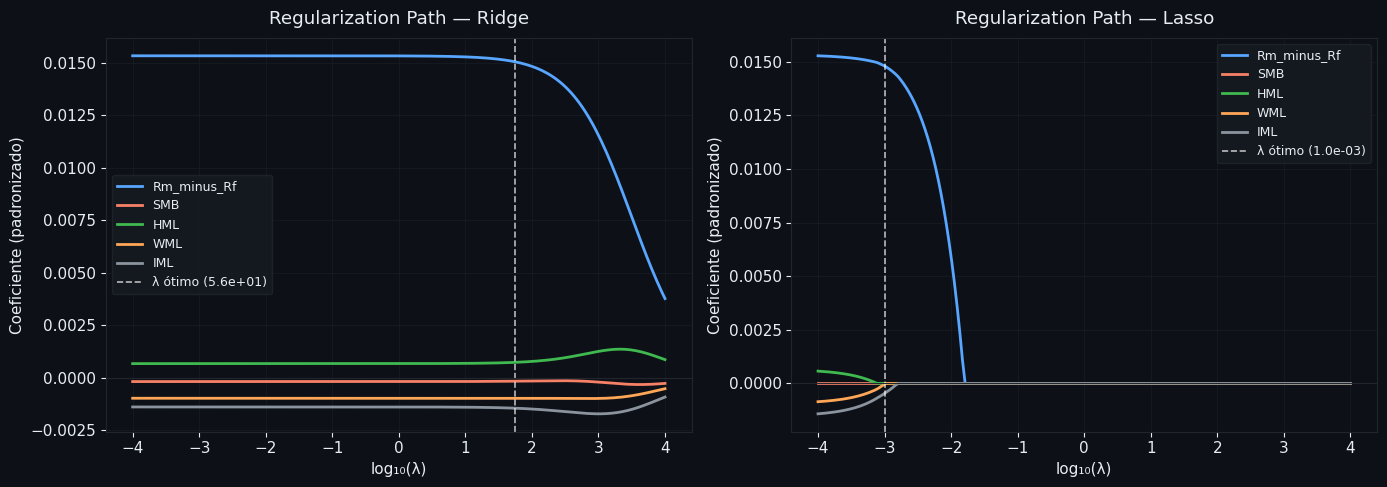

In [12]:
cores_fatores = [BLUE, RED, GREEN, GOLD, GRAY]
alphas_path   = np.logspace(-4, 4, 200)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, Modelo, nome, lambda_otimo in [
    (axes[0], Ridge,  'Ridge', ridge_cv.alpha_),
    (axes[1], Lasso,  'Lasso', lasso_cv.alpha_),
]:
    paths = np.array([Modelo(alpha=a, max_iter=20000).fit(X_train_sc, y_train).coef_
                      for a in alphas_path])

    for i, (fator, cor) in enumerate(zip(FEATURES, cores_fatores)):
        ax.plot(np.log10(alphas_path), paths[:, i], color=cor, lw=2, label=fator)

    ax.axvline(np.log10(lambda_otimo), color='white', lw=1.2,
               ls='--', alpha=0.7, label=f'λ ótimo ({lambda_otimo:.1e})')
    ax.axhline(0, color=GRID, lw=0.8)

    ax.set_xlabel('log₁₀(λ)', color=TEXT)
    ax.set_ylabel('Coeficiente (padronizado)', color=TEXT)
    ax.set_title(f'Regularization Path — {nome}', color=TEXT, pad=10)
    ax.legend(fontsize=9)
    ax.grid(True)

fig.patch.set_facecolor(BG)
plt.tight_layout()
plt.show()

### 5.3 Coeficientes por modelo

A comparação direta mostra o efeito da regularização: coeficientes encolhidos pelo Ridge, zerados pelo Lasso, e o comportamento intermediário do Elastic Net.

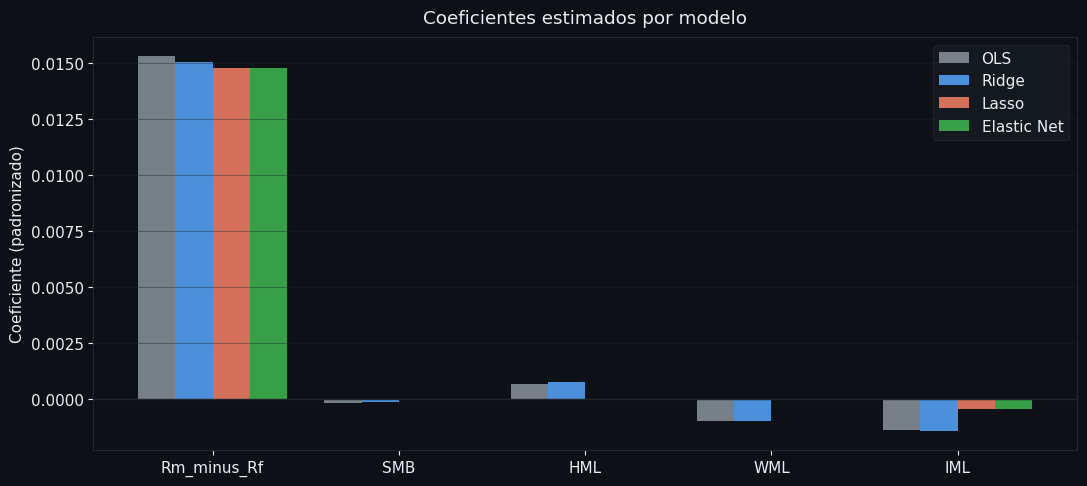


Coeficientes iguais a zero no Lasso indicam fatores que não contribuem
significativamente para explicar o retorno em excesso do ITUB4.


In [13]:
nomes_modelos  = list(modelos.keys())
cores_modelos  = [GRAY, BLUE, RED, GREEN]
x = np.arange(len(FEATURES))
largura = 0.2

fig, ax = plt.subplots(figsize=(11, 5))

for i, (nome, modelo) in enumerate(modelos.items()):
    coefs = modelo.coef_ if hasattr(modelo, 'coef_') else modelo.coef_
    ax.bar(x + i * largura, coefs, largura,
           label=nome, color=cores_modelos[i], alpha=0.85)

ax.axhline(0, color=GRID, lw=1)
ax.set_xticks(x + largura * 1.5)
ax.set_xticklabels(FEATURES, color=TEXT)
ax.set_ylabel('Coeficiente (padronizado)', color=TEXT)
ax.set_title('Coeficientes estimados por modelo', color=TEXT, pad=10)
ax.legend()
ax.grid(True, axis='y')
fig.patch.set_facecolor(BG)
plt.tight_layout()
plt.show()

print("\nCoeficientes iguais a zero no Lasso indicam fatores que não contribuem")
print("significativamente para explicar o retorno em excesso do ITUB4.")

### 5.4 Estabilidade temporal — coeficientes e λ rolling

Um único λ calibrado sobre toda a amostra assume que os pesos dos fatores são constantes no tempo. Para testar essa premissa, repetimos o ajuste do Lasso com **expanding window**: a cada passo (~mensal), adicionamos 21 dias úteis à janela de treino, re-padronizamos os preditores e re-calibramos λ por validação cruzada temporal.

O resultado mostra como os coeficientes e o λ ótimo evoluem à medida que o modelo "aprende" mais dados — revelando períodos de instabilidade que o modelo estático não captura.

In [14]:
from sklearn.preprocessing import StandardScaler as _SC
from sklearn.linear_model import LassoCV as _LCV
from sklearn.model_selection import TimeSeriesSplit as _TSS

MIN_WINDOW    = 500          # observações mínimas para o 1º ajuste (~2 anos)
STEP          = 21           # passo em dias úteis (~mensal)
alphas_roll   = np.logspace(-4, 2, 80)
tscv_roll     = _TSS(n_splits=3)

records = []
indices = range(MIN_WINDOW, len(df), STEP)
total   = len(list(indices))

for k, end_idx in enumerate(indices):
    X_w = X[:end_idx]
    y_w = y[:end_idx]

    sc_w     = _SC()
    X_w_sc   = sc_w.fit_transform(X_w)

    lasso_w  = _LCV(alphas=alphas_roll, cv=tscv_roll, max_iter=10000)
    lasso_w.fit(X_w_sc, y_w)

    records.append({
        'date':   df.index[end_idx - 1],
        'lambda': lasso_w.alpha_,
        **dict(zip(FEATURES, lasso_w.coef_))
    })

    if (k + 1) % 20 == 0 or (k + 1) == total:
        print(f"  {k+1}/{total} janelas ajustadas...")

rolling_df = pd.DataFrame(records).set_index('date')
print(f"\nPronto. {len(rolling_df)} janelas | "
      f"{rolling_df.index.min().date()} → {rolling_df.index.max().date()}")
rolling_df.head(3)

  20/169 janelas ajustadas...
  40/169 janelas ajustadas...
  60/169 janelas ajustadas...
  80/169 janelas ajustadas...
  100/169 janelas ajustadas...
  120/169 janelas ajustadas...
  140/169 janelas ajustadas...
  160/169 janelas ajustadas...
  169/169 janelas ajustadas...

Pronto. 169 janelas | 2012-01-06 → 2026-04-06


,lambda,Rm_minus_Rf,SMB,HML,WML,IML
date,,,,,,
2012-01-06,0.000575,0.013682,-0.0,-0.0,0.000226,-0.001116
2012-02-07,0.000815,0.013256,-0.0,-0.0,0.000000,-0.000925
2012-03-12,0.001378,0.012834,-0.0,-0.0,0.000000,-0.000426


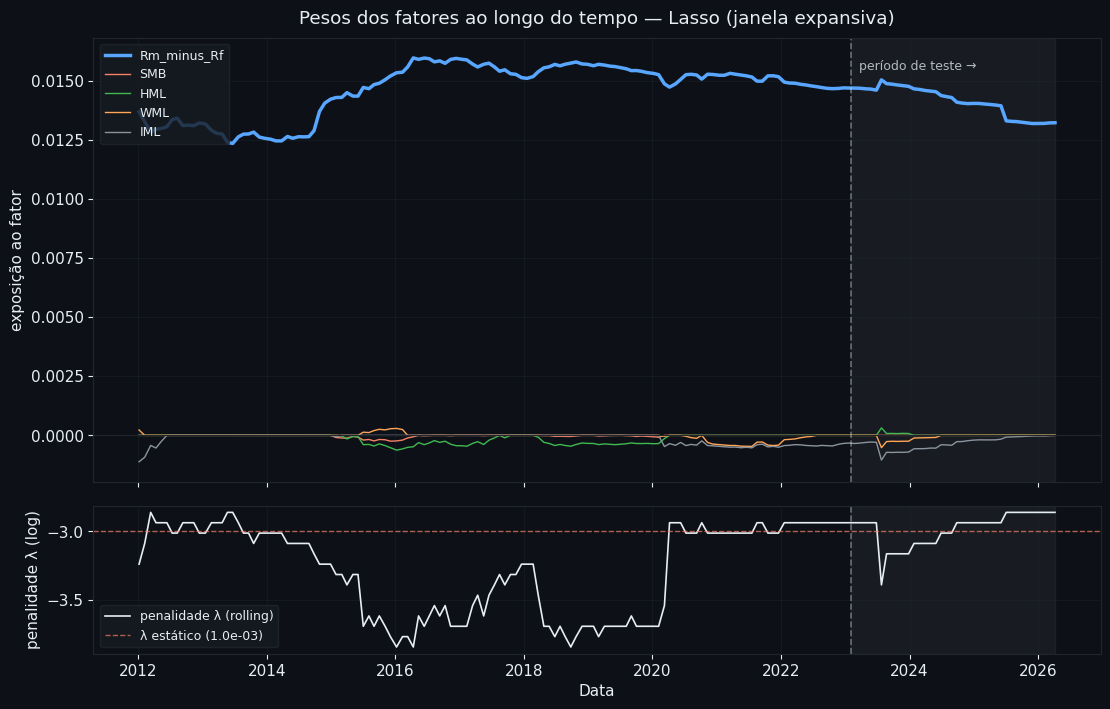

Proporção do tempo em que cada fator foi zerado pelo Lasso rolling:
  Rm_minus_Rf       0.0% do tempo zerado
  SMB              78.1% do tempo zerado
  HML              64.5% do tempo zerado
  WML              74.0% do tempo zerado
  IML              52.7% do tempo zerado


In [15]:
cores_fatores = [BLUE, RED, GREEN, GOLD, GRAY]
lws           = [2.5, 1.0, 1.0, 1.0, 1.0]   # Rm−Rf em destaque

test_start = df.index[split]
x_end      = rolling_df.index.max()

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.08})

# ── painel superior: coeficientes rolling ────────────────────────────────────────
ax = axes[0]
ax.axvspan(test_start, x_end, color=TEXT, alpha=0.05, zorder=0, label='_nolegend_')

for fator, cor, lw in zip(FEATURES, cores_fatores, lws):
    ax.plot(rolling_df.index, rolling_df[fator], color=cor, lw=lw, label=fator)

ax.axhline(0, color=GRID, lw=0.8)
ax.axvline(test_start, color=TEXT, lw=1.2, ls='--', alpha=0.4)
ax.text(test_start, 0.95, '  período de teste →',
        transform=ax.get_xaxis_transform(),
        color=TEXT, fontsize=9, alpha=0.75, va='top')

ax.set_ylabel('exposição ao fator', color=TEXT)
ax.set_title('Pesos dos fatores ao longo do tempo — Lasso (janela expansiva)', color=TEXT, pad=10)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True)

# ── painel inferior: λ ótimo rolling ──────────────────────────────────────────
ax2 = axes[1]
ax2.axvspan(test_start, x_end, color=TEXT, alpha=0.05, zorder=0)

ax2.plot(rolling_df.index, np.log10(rolling_df['lambda']),
         color=TEXT, lw=1.2, label='penalidade λ (rolling)')
ax2.axhline(np.log10(lasso_cv.alpha_), color=RED, lw=1, ls='--', alpha=0.7,
            label=f'λ estático ({lasso_cv.alpha_:.1e})')
ax2.axvline(test_start, color=TEXT, lw=1.2, ls='--', alpha=0.4)

ax2.set_ylabel('penalidade λ (log)', color=TEXT)
ax2.set_xlabel('Data', color=TEXT)
ax2.legend(fontsize=9)
ax2.grid(True)

fig.patch.set_facecolor(BG)
for a in axes:
    a.set_facecolor(BG)
plt.tight_layout()
plt.show()

# ── resumo de instabilidade ─────────────────────────────────────────────────────
print("Proporção do tempo em que cada fator foi zerado pelo Lasso rolling:")
for fator in FEATURES:
    pct_zero = (rolling_df[fator] == 0).mean() * 100
    print(f"  {fator:<15} {pct_zero:5.1f}% do tempo zerado")


### 5.5 Robustez na frequência mensal

Os fatores SMB e HML do modelo Fama-French foram originalmente calibrados para explicar retornos mensais — o horizonte natural de formação de portfólios. Com dados diários, o sinal desses fatores é dominado por ruído de curto prazo, o que pode levar o Lasso a zerá-los não por falta de relevância, mas por relação sinal/ruído desfavorável.

Para testar essa hipótese, agregamos os retornos diários à frequência mensal por capitalização composta e repetimos o pipeline de OLS e Lasso nessa nova frequência. Se SMB e HML sobreviverem à agregação mensal, o sinal existe mas estava mascarado pelo ruído intradiário; se continuarem zerados, a eliminação é robusta ao horizonte.

In [16]:
# Agrega retornos diários a mensais por capitalização composta
monthly = (df[FEATURES + ['R_excess']]
           .resample('ME')
           .apply(lambda x: (1 + x).prod() - 1)
           .dropna())

X_m = monthly[FEATURES].values
y_m = monthly['R_excess'].values

split_m     = int(len(monthly) * 0.80)
X_m_tr, X_m_te = X_m[:split_m], X_m[split_m:]
y_m_tr, y_m_te = y_m[:split_m], y_m[split_m:]

date_m_tr_end   = monthly.index[split_m - 1].date()
date_m_te_start = monthly.index[split_m].date()

scaler_m  = StandardScaler()
X_m_tr_sc = scaler_m.fit_transform(X_m_tr)
X_m_te_sc = scaler_m.transform(X_m_te)

alphas_m = np.logspace(-4, 2, 100)
tscv_m   = TimeSeriesSplit(n_splits=5)

ols_m   = LinearRegression().fit(X_m_tr_sc, y_m_tr)
lasso_m = LassoCV(alphas=alphas_m, cv=tscv_m, max_iter=20000)
lasso_m.fit(X_m_tr_sc, y_m_tr)

print(f"Amostra mensal: {monthly.index.min().date()} → {monthly.index.max().date()} ({len(monthly)} meses)")
print(f"Treino: → {date_m_tr_end} ({split_m} meses)  |  Teste: {date_m_te_start} → ({len(monthly)-split_m} meses)")
print(f"\nλ ótimo Lasso (mensal): {lasso_m.alpha_:.6f}")

print(f"\n{'Fator':<15} {'Diário':>12} {'Mensal':>12}")
print("-" * 44)
for nome, cd, cm in zip(FEATURES, lasso_cv.coef_, lasso_m.coef_):
    flag_d = " ← zerado" if cd == 0 else ""
    flag_m = " ← zerado" if cm == 0 else ""
    print(f"{nome:<15} {cd:+.6f}{flag_d:<10}  {cm:+.6f}{flag_m}")

print(f"\nOLS   R² teste (mensal): {r2_score(y_m_te, ols_m.predict(X_m_te_sc)):.4f}")
print(f"Lasso R² teste (mensal): {r2_score(y_m_te, lasso_m.predict(X_m_te_sc)):.4f}")
print("\nNota: R² mensal não é comparável ao R² diário — retornos mensais têm variância")
print("maior por agregação temporal, o que infla o R² mensal independentemente do modelo.")
print("Compare apenas a seleção de fatores (quais foram zerados) entre as duas frequências.")


Amostra mensal: 2010-01-31 → 2026-05-31 (197 meses)
Treino: → 2023-01-31 (157 meses)  |  Teste: 2023-02-28 → (40 meses)

λ ótimo Lasso (mensal): 0.006579

Fator                 Diário       Mensal
--------------------------------------------
Rm_minus_Rf     +0.014792            +0.065143
SMB             -0.000000 ← zerado   -0.000000 ← zerado
HML             +0.000000 ← zerado   +0.000000 ← zerado
WML             -0.000018            -0.000000 ← zerado
IML             -0.000454            -0.000000 ← zerado

OLS   R² teste (mensal): 0.6732
Lasso R² teste (mensal): 0.7101

Nota: R² mensal não é comparável ao R² diário — retornos mensais têm variância
maior por agregação temporal, o que infla o R² mensal independentemente do modelo.
Compare apenas a seleção de fatores (quais foram zerados) entre as duas frequências.


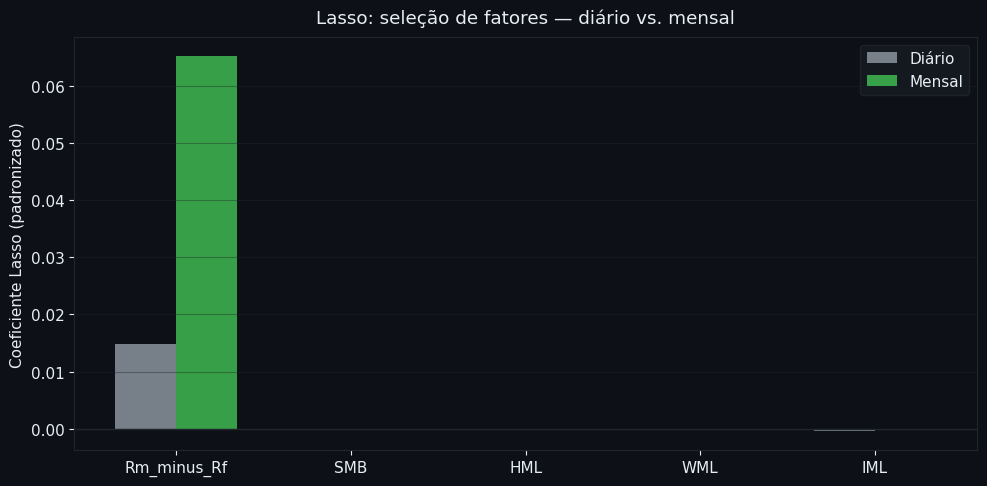

Barras ausentes (altura zero) = fator zerado pelo Lasso naquela frequência.
Nota: as alturas não são comparáveis entre diário (cinza) e mensal (verde) —
coeficientes mensais têm escala ~√21 ≈ 4,6× maior por pura agregação temporal.
Observe presença/ausência das barras, não a magnitude.


In [17]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(FEATURES))
w = 0.35

ax.bar(x - w/2, lasso_cv.coef_, w, label='Diário',  color=GRAY,  alpha=0.85)
ax.bar(x + w/2, lasso_m.coef_,  w, label='Mensal',  color=GREEN, alpha=0.85)

ax.axhline(0, color=GRID, lw=1)
ax.set_xticks(x)
ax.set_xticklabels(FEATURES, color=TEXT)
ax.set_ylabel('Coeficiente Lasso (padronizado)', color=TEXT)
ax.set_title('Lasso: seleção de fatores — diário vs. mensal', color=TEXT, pad=10)
ax.legend()
ax.grid(True, axis='y')
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
plt.tight_layout()
plt.show()

print("Barras ausentes (altura zero) = fator zerado pelo Lasso naquela frequência.")
print("Nota: as alturas não são comparáveis entre diário (cinza) e mensal (verde) —")
print("coeficientes mensais têm escala ~√21 ≈ 4,6× maior por pura agregação temporal.")
print("Observe presença/ausência das barras, não a magnitude.")


### 5.6 Janela deslizante — resposta à não-estacionariedade

O modelo estático usa toda a amostra de treino (2010–2023), assumindo implicitamente que os pesos dos fatores são constantes ao longo do tempo. A análise rolling (5.4) mostrou que essa premissa é violada: coeficientes e λ ótimo variam por regime.

Uma resposta direta é usar uma **janela deslizante de tamanho fixo**: em vez de toda a amostra histórica, usamos apenas as observações mais recentes. A janela captura o regime vigente sem ser contaminada por regimes antigos — ao custo de descartar dados históricos potencialmente informativos.

Avaliamos o trade-off: modelo estático (treino sobre toda a amostra) contra modelo deslizante (últimos 500 dias úteis antes do corte de treino/teste), comparando R² e RMSE no conjunto de teste. Um R² superior ao modelo estático indica que o regime recente difere o suficiente para justificar descartar dados antigos; um R² inferior indica que o histórico ainda é informativo.

O resultado dessa comparação é específico ao período de teste e ao valor WIN=500 escolhido: outro tamanho de janela poderia inverter o resultado. A análise responde se, *neste período*, o regime recente era suficientemente distinto do histórico — não se a janela deslizante é universalmente superior ao modelo estático.

In [18]:
WIN = 500  # ~2 anos de dados diários

# Janela deslizante: últimas WIN observações antes do split
X_sl = X[split - WIN : split]
y_sl = y[split - WIN : split]

date_sl_start = df.index[split - WIN].date()
date_sl_end   = df.index[split - 1].date()

scaler_sl  = StandardScaler()
X_sl_sc    = scaler_sl.fit_transform(X_sl)
X_te_sl_sc = scaler_sl.transform(X_test)

lasso_sl = LassoCV(alphas=alphas, cv=TimeSeriesSplit(n_splits=5), max_iter=20000)
lasso_sl.fit(X_sl_sc, y_sl)

print(f"Janela deslizante: {date_sl_start} → {date_sl_end} ({WIN} obs)")

r2_st   = r2_score(y_test, lasso_cv.predict(X_test_sc))
r2_sl   = r2_score(y_test, lasso_sl.predict(X_te_sl_sc))
rmse_st = np.sqrt(mean_squared_error(y_test, lasso_cv.predict(X_test_sc)))
rmse_sl = np.sqrt(mean_squared_error(y_test, lasso_sl.predict(X_te_sl_sc)))

print(f"\n{'Modelo':<37} {'R² teste':>10} {'RMSE teste':>12}")
print("-" * 62)
print(f"{'Lasso estático (treino completo)':<37} {r2_st:>10.4f} {rmse_st:>12.6f}")
print(f"{'Lasso deslizante (WIN=500 dias)':<37} {r2_sl:>10.4f} {rmse_sl:>12.6f}")

print(f"\nλ ótimo — estático: {lasso_cv.alpha_:.6f}  |  deslizante: {lasso_sl.alpha_:.6f}")

print(f"\n{'Fator':<15} {'Estático':>12} {'Deslizante':>12}")
print("-" * 42)
for nome, c_st, c_sl in zip(FEATURES, lasso_cv.coef_, lasso_sl.coef_):
    flag_st = " ← zerado" if c_st == 0 else ""
    flag_sl = " ← zerado" if c_sl == 0 else ""
    print(f"{nome:<15} {c_st:+.6f}{flag_st:<10}  {c_sl:+.6f}{flag_sl}")


Janela deslizante: 2021-02-01 → 2023-01-31 (500 obs)

Modelo                                  R² teste   RMSE teste
--------------------------------------------------------------
Lasso estático (treino completo)          0.3048     0.011338
Lasso deslizante (WIN=500 dias)           0.3546     0.010924

λ ótimo — estático: 0.001012  |  deslizante: 0.001607

Fator               Estático   Deslizante
------------------------------------------
Rm_minus_Rf     +0.014792            +0.011545
SMB             -0.000000 ← zerado   -0.000000 ← zerado
HML             +0.000000 ← zerado   +0.000869
WML             -0.000018            +0.000000 ← zerado
IML             -0.000454            -0.000000 ← zerado


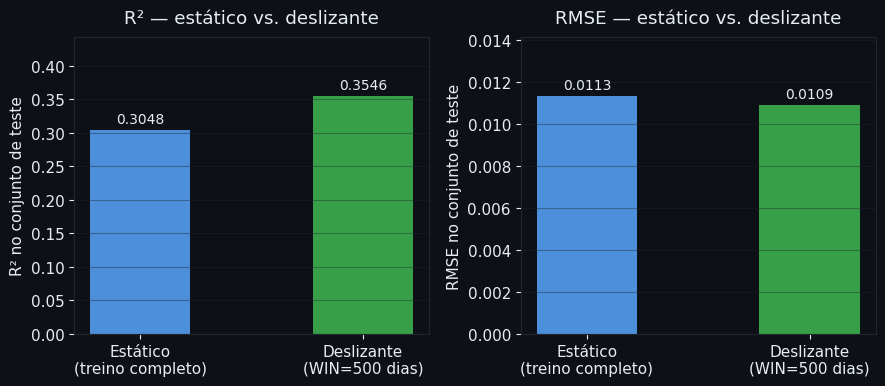

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

rotulos   = ['Estático\n(treino completo)', 'Deslizante\n(WIN=500 dias)']
r2_vals   = [r2_st,   r2_sl]
rmse_vals = [rmse_st, rmse_sl]
cores_c   = [BLUE, GREEN]

for ax, vals, ylabel, title in [
    (axes[0], r2_vals,   'R² no conjunto de teste',   'R² — estático vs. deslizante'),
    (axes[1], rmse_vals, 'RMSE no conjunto de teste',  'RMSE — estático vs. deslizante'),
]:
    bars = ax.bar(rotulos, vals, color=cores_c, alpha=0.85, width=0.45)
    ax.set_ylabel(ylabel, color=TEXT)
    ax.set_title(title, color=TEXT, pad=10)
    ax.set_ylim(0, max(vals) * 1.25)
    ax.grid(True, axis='y')
    ax.set_facecolor(BG)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + max(vals) * 0.03,
                f'{v:.4f}', ha='center', color=TEXT, fontsize=10)

fig.patch.set_facecolor(BG)
plt.tight_layout()
plt.show()


## Fase 6 — Conclusão

### O que os modelos revelaram

O prêmio de mercado (Rm − Rf) é, como esperado, o fator dominante: a exposição ao mercado é o principal determinante do retorno do ITUB4 — consistente com o resultado do notebook 01.

O Lasso, treinado nos dados diários, identificou dois fatores com contribuição insuficiente para justificar coeficientes não-nulos: SMB e HML foram zerados, enquanto WML (momentum) e IML (iliquidez) sobreviveram com coeficientes negativos pequenos. O Elastic Net confirmou essa seleção (l1_ratio ótimo próximo de 1).

### Análises de robustez (5.5 e 5.6)

**Frequência mensal (5.5)** — o Lasso mensal zerou todos os fatores exceto Rm−Rf, incluindo WML e IML que haviam sobrevivido na versão diária. A hipótese inicial era que SMB e HML sobreviveriam em seu horizonte nativo — isso não aconteceu. O resultado reforça a conclusão de que apenas o prêmio de mercado tem sinal robusto para o ITUB4, mesmo na frequência mensal. Uma ressalva importante: o modelo mensal dispõe de ~158 meses de treino (contra 3.237 dias na versão diária), o que pode levar o CV a selecionar um λ mais conservador e zerear mais coeficientes por limitação de amostra — não necessariamente por ausência de sinal.

**Janela deslizante (5.6)** — o modelo treinado nos últimos 500 dias antes do corte (jan/2021–jan/2023) obteve R² = 0,3546 no conjunto de teste, contra R² = 0,3048 do modelo estático — uma melhora relativa de ~16%. O resultado confirma que o regime 2021–2023 era mais representativo do período de teste (2023–2026) do que o histórico completo desde 2010, tornando a não-estacionariedade um problema preditivo concreto e quantificável neste caso. A conclusão é específica a WIN=500 e a este período de teste.

### Ressalva de interpretação

Os coeficientes regularizados são viesados por construção — essa é a propriedade que melhora a predição, não um defeito. Para o objetivo desta análise (predição), o viés não é um problema. Torna-se limitação apenas se os coeficientes forem reinterpretados como efeitos causais, o que exigiria o *debiased Lasso*.

### Próximo passo

- **Notebook 03 — Classificação regularizada**: modelar a *direção* do retorno do ITUB4 (alta ou queda) com regressão logística penalizada, aplicando os mesmos três métodos a um problema de classificação binária.